# Global Misinformation Analysis: GDELT-Based Event Dataset

**Research questions**
1. What types of misinformation themes appear in global news reporting?
2. Where are these events geographically concentrated?
3. Under what political, economic, or public health conditions does misinformation activity increase?

**Methods:** LDA topic modelling (theme identification) · DBSCAN / Moran's I / KDE (spatial hotspots) · Poisson / Negative Binomial regression (contextual drivers)

**Input file:** `gdelt_analytical_dataset_v1.xlsx`

> Update `DATA_PATH` in the cell below to point to wherever you saved the Excel file on your machine, then run the notebook top to bottom.


## 1. Environment setup

Run the cell below **once** in an Anaconda Prompt / terminal (with your environment activated) if any of these packages are missing. It is commented out so it doesn't run automatically inside the notebook.

In [1]:
# Run this cell once to install missing packages directly into THIS notebook's kernel.
# After it finishes, go to Kernel -> Restart Kernel, then run the notebook from the top.

%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels gensim scipy
%pip install geopandas libpysal esda shapely


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Core data handling
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Text / NLP
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel

# Spatial analysis
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import libpysal
from libpysal.weights import KNN
from esda.moran import Moran
from scipy.stats import gaussian_kde

# Statistical modelling
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load and inspect the analytical dataset

In [3]:
DATA_PATH = "gdelt_analytical_dataset_v1.xlsx"   # <-- update this path if needed

df_raw = pd.read_excel(DATA_PATH)

print("Shape:", df_raw.shape)
df_raw.head()


Shape: (500, 24)


,Record_ID,Date,Year,Month,Month_Name,Quarter,Year_Month,Source,Source_URL,Country,...,Number_of_Themes,Misinfo_Flag,Tone_Overall,Tone_Positive,Tone_Negative,Tone_Polarity,Tone_Activity,Tone_SelfGroup,Context_Category,Tone_Category
0,GDELT-SYNTHETIC-20220101-00333,2022-01-01,2022,1,January,Q1,2022-01,The Guardian,https://www.theguardian.com/news/2022/01/01/so...,Brazil,...,4,1,-0.21,1.88,0.15,2.03,6.18,3.80,CRISISLEX_C07;15;1;Brazil;-14.23;-51.92,Neutral
1,GDELT-SYNTHETIC-20220102-00214,2022-01-02,2022,1,January,Q1,2022-01,Deutsche Welle,https://www.dw.com/news/2022/01/02/fact-check-...,Ghana,...,6,1,-6.30,0.71,7.88,8.59,6.60,2.85,ARREST;34;1;Ghana;7.94;-1.02,Negative
2,GDELT-SYNTHETIC-20220105-00391,2022-01-05,2022,1,January,Q1,2022-01,Al Jazeera,https://www.aljazeera.com/news/2022/01/05/poli...,United Kingdom,...,6,1,-7.93,3.26,8.48,11.74,6.04,1.90,ARREST;19;1;United Kingdom;55.37;-3.43,Negative
3,GDELT-SYNTHETIC-20220106-00173,2022-01-06,2022,1,January,Q1,2022-01,Al Jazeera,https://www.aljazeera.com/news/2022/01/06/fact...,Ukraine,...,4,1,-2.99,0.48,4.76,5.24,13.39,1.89,PROTEST;23;1;Ukraine;48.37;31.16,Negative
4,GDELT-SYNTHETIC-20220108-00334,2022-01-08,2022,1,January,Q1,2022-01,The Guardian,https://www.theguardian.com/news/2022/01/08/re...,Mexico,...,3,1,-3.56,1.00,4.31,5.31,10.52,3.05,ARREST;17;1;Mexico;23.63;-102.55,Negative


In [4]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Record_ID         500 non-null    object        
 1   Date              500 non-null    datetime64[ns]
 2   Year              500 non-null    int64         
 3   Month             500 non-null    int64         
 4   Month_Name        500 non-null    object        
 5   Quarter           500 non-null    object        
 6   Year_Month        500 non-null    object        
 7   Source            500 non-null    object        
 8   Source_URL        500 non-null    object        
 9   Country           500 non-null    object        
 10  Latitude          500 non-null    float64       
 11  Longitude         500 non-null    float64       
 12  Themes            500 non-null    object        
 13  Theme_Count       500 non-null    int64         
 14  Number_of_Themes  500 non-

In [5]:
df_raw.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Record_ID,500,500,GDELT-SYNTHETIC-20220101-00333,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,500,NaN,NaN,NaN,2023-01-14 06:37:26.400000,2022-01-01 00:00:00,2022-07-12 00:00:00,2023-01-27 00:00:00,2023-07-17 12:00:00,2024-01-01 00:00:00,NaN
Year,500.0,NaN,NaN,NaN,2022.54,2022.0,2022.0,2023.0,2023.0,2024.0,0.506867
Month,500.0,NaN,NaN,NaN,6.5,1.0,3.0,7.0,10.0,12.0,3.446993
Month_Name,500,12,October,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quarter,500,4,Q3,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_Month,500,25,2022-10,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,500,7,France 24,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source_URL,500,500,https://www.theguardian.com/news/2022/01/01/so...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,500,20,South Africa,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Confirm the key columns we rely on throughout the notebook are present and typed correctly
required_cols = [
    "Record_ID", "Date", "Year", "Month", "Year_Month",
    "Country", "Latitude", "Longitude",
    "Themes", "Theme_Count", "Misinfo_Flag",
    "Tone_Overall", "Tone_Positive", "Tone_Negative",
    "Context_Category", "Tone_Category"
]
missing_cols = [c for c in required_cols if c not in df_raw.columns]
print("Missing required columns:", missing_cols if missing_cols else "None")

df_raw.dtypes[required_cols]


Missing required columns: None


Record_ID                   object
Date                datetime64[ns]
Year                         int64
Month                        int64
Year_Month                  object
Country                     object
Latitude                   float64
Longitude                  float64
Themes                      object
Theme_Count                  int64
Misinfo_Flag                 int64
Tone_Overall               float64
Tone_Positive              float64
Tone_Negative              float64
Context_Category            object
Tone_Category               object
dtype: object

## 3. Clean and preprocess the data

In [7]:
df = df_raw.copy()

# --- Deduplicate on the unique event identifier ---
before = len(df)
df = df.drop_duplicates(subset=["Record_ID"])
print(f"Removed {before - len(df)} duplicate rows (by Record_ID). Remaining: {len(df)}")

# --- Keep only confirmed misinformation events ---
before = len(df)
df = df[df["Misinfo_Flag"] == 1].copy()
print(f"Filtered to Misinfo_Flag == 1: {len(df)} of {before} rows retained")


Removed 0 duplicate rows (by Record_ID). Remaining: 500
Filtered to Misinfo_Flag == 1: 500 of 500 rows retained


In [8]:
# --- Missing values ---
na_summary = df.isna().sum()
na_summary = na_summary[na_summary > 0]
print("Columns with missing values:")
print(na_summary if len(na_summary) else "None - dataset is complete")

# Drop rows that are unusable for spatial analysis (no coordinates) or have no theme info
df = df.dropna(subset=["Latitude", "Longitude", "Themes"])

# For any missing tone scores, fill with the column median rather than dropping the event
tone_cols = ["Tone_Overall", "Tone_Positive", "Tone_Negative", "Tone_Polarity", "Tone_Activity", "Tone_SelfGroup"]
for c in tone_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())


Columns with missing values:
None - dataset is complete


In [9]:
# --- Standardise country names (extend this mapping as new spellings appear in your data) ---
country_map = {
    "United States": "USA",
    "United States of America": "USA",
    "U.S.": "USA",
    "UK": "United Kingdom",
    "Great Britain": "United Kingdom",
}
df["Country"] = df["Country"].replace(country_map)
print("Unique countries after standardisation:", df["Country"].nunique())


Unique countries after standardisation: 20


In [10]:
# --- Time variables ---
df["Date"] = pd.to_datetime(df["Date"])

# Rebuild Year/Month/Year_Month from Date to guarantee internal consistency
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

print(df[["Date", "Year", "Month", "Year_Month"]].head())
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())


        Date  Year  Month Year_Month
0 2022-01-01  2022      1    2022-01
1 2022-01-02  2022      1    2022-01
2 2022-01-05  2022      1    2022-01
3 2022-01-06  2022      1    2022-01
4 2022-01-08  2022      1    2022-01
Date range: 2022-01-01 to 2024-01-01


## 4. Theme identification via LDA (misinformation types)

Each event's `Themes` field (e.g. `"ELECTION; CYBER_ATTACK; VACCINE_MISINFORMATION"`) is treated as a short "document" made up of GDELT theme tags. LDA is fit on this theme-token corpus to discover latent misinformation topics, and each event is assigned its single most probable topic.

In [11]:
# --- Tokenise the Themes field into lists ---
df["Theme_Tokens"] = df["Themes"].apply(
    lambda s: [t.strip() for t in str(s).split(";") if t.strip()]
)

print(df[["Themes", "Theme_Tokens"]].head(3))


                                              Themes  \
0  ELECTION; CYBER_ATTACK; VACCINE_MISINFORMATION...   
1  TAX_FNCACT_POLITICIAN; CRISISLEX_CRISISLEXREC;...   
2  DISINFORMATION; WB_MEDIA; ELECTION; CYBER_ATTA...   

                                        Theme_Tokens  
0  [ELECTION, CYBER_ATTACK, VACCINE_MISINFORMATIO...  
1  [TAX_FNCACT_POLITICIAN, CRISISLEX_CRISISLEXREC...  
2  [DISINFORMATION, WB_MEDIA, ELECTION, CYBER_ATT...  


In [12]:
# --- Build gensim dictionary and bag-of-words corpus ---
texts = df["Theme_Tokens"].tolist()

dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

print(f"Vocabulary size: {len(dictionary)}")
print(f"Number of documents (events): {len(corpus)}")


Vocabulary size: 20
Number of documents (events): 500


num_topics=3  coherence(c_v)=0.0525
num_topics=4  coherence(c_v)=0.0525
num_topics=5  coherence(c_v)=0.0525
num_topics=6  coherence(c_v)=0.0525
num_topics=7  coherence(c_v)=0.0525
num_topics=8  coherence(c_v)=0.0525


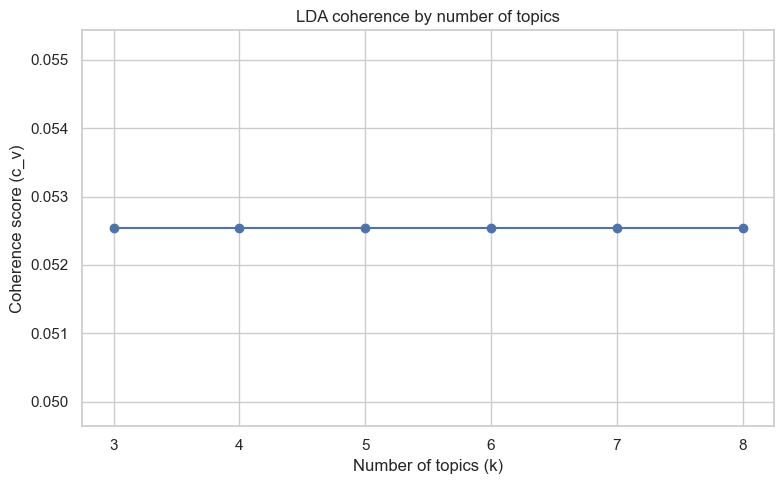

In [13]:
# --- Try a range of topic counts and compare coherence (c_v) ---
topic_range = range(3, 9)
coherence_scores = []

for k in topic_range:
    lda_k = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=20,
        alpha="auto",
        per_word_topics=False,
    )
    cm = CoherenceModel(model=lda_k, texts=texts, dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"num_topics={k}  coherence(c_v)={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(topic_range), coherence_scores, marker="o")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence score (c_v)")
plt.title("LDA coherence by number of topics")
plt.tight_layout()
plt.show()


In [14]:
# --- Fit the final LDA model with the best-scoring number of topics ---
NUM_TOPICS = list(topic_range)[int(np.argmax(coherence_scores))]
print(f"Selected NUM_TOPICS = {NUM_TOPICS} (highest coherence)")

# You can override NUM_TOPICS manually here if you prefer a more interpretable number, e.g.:
# NUM_TOPICS = 5

lda_model = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=50,
    alpha="auto",
    per_word_topics=False,
)

for idx, topic in lda_model.print_topics(num_words=6):
    print(f"Topic {idx}: {topic}")


Selected NUM_TOPICS = 5 (highest coherence)
Topic 0: 0.161*"TAX_FNCACT_JOURNALIST" + 0.137*"CRISISLEX_CRISISLEXREC" + 0.127*"INFORMATION_OPERATIONS" + 0.074*"SOC_POINTSOFINTEREST" + 0.068*"FAKE_NEWS" + 0.065*"CYBER_ATTACK"
Topic 1: 0.221*"TAX_FNCACT_POLITICIAN" + 0.123*"CONSPIRACY" + 0.096*"CRISISLEX_CRISISLEXREC" + 0.093*"GOV_GOVERNMENT_GENERAL" + 0.092*"PROPAGANDA" + 0.092*"CYBER_ATTACK"
Topic 2: 0.216*"ELECTION" + 0.150*"GOV_GOVERNMENT_GENERAL" + 0.094*"FAKE_NEWS" + 0.070*"PROPAGANDA" + 0.069*"CYBER_ATTACK" + 0.060*"CRISISLEX_T10_URGENCY"
Topic 3: 0.161*"ELECTION_FRAUD" + 0.146*"DISINFORMATION" + 0.133*"WB_MEDIA" + 0.112*"FAKE_NEWS" + 0.079*"TAX_FNCACT_POLITICIAN" + 0.073*"WB_HEALTH"
Topic 4: 0.259*"ECON_BANKRUPTCY" + 0.108*"WB_HEALTH" + 0.092*"VACCINE_MISINFORMATION" + 0.092*"MEDIA_MANIPULATION" + 0.083*"SOC_POINTSOFINTEREST" + 0.075*"CLIMATE_DENIAL"


In [15]:
# --- Assign the dominant topic to each event ---
def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    return max(topic_probs, key=lambda x: x[1])[0] if topic_probs else None

df["Topic_ID"] = [get_dominant_topic(bow) for bow in corpus]

# Human-readable labels: inspect the top words per topic and name them accordingly.
# Edit this dictionary once you've looked at the printed topics above.
topic_labels = {i: f"Topic {i}" for i in range(NUM_TOPICS)}
# Example manual overrides once you've inspected the topics:
# topic_labels = {0: "Political misinformation", 1: "Health misinformation",
#                  2: "Cyber/Information operations", 3: "Economic misinformation", 4: "Media manipulation"}

df["Topic_Label"] = df["Topic_ID"].map(topic_labels)

df[["Record_ID", "Themes", "Topic_ID", "Topic_Label"]].head(10)


,Record_ID,Themes,Topic_ID,Topic_Label
0,GDELT-SYNTHETIC-20220101-00333,ELECTION; CYBER_ATTACK; VACCINE_MISINFORMATION...,2,Topic 2
1,GDELT-SYNTHETIC-20220102-00214,TAX_FNCACT_POLITICIAN; CRISISLEX_CRISISLEXREC;...,0,Topic 0
2,GDELT-SYNTHETIC-20220105-00391,DISINFORMATION; WB_MEDIA; ELECTION; CYBER_ATTA...,3,Topic 3
3,GDELT-SYNTHETIC-20220106-00173,FAKE_NEWS; WB_HEALTH; ELECTION_FRAUD; CRISISLE...,3,Topic 3
4,GDELT-SYNTHETIC-20220108-00334,CRISISLEX_CRISISLEXREC; GOV_GOVERNMENT_GENERAL...,0,Topic 0
5,GDELT-SYNTHETIC-20220110-00168,ECON_BANKRUPTCY; MEDIA_MANIPULATION; WB_HEALTH,4,Topic 4
6,GDELT-SYNTHETIC-20220112-00405,CYBER_ATTACK; WB_HEALTH; CRISISLEX_T10_URGENCY...,0,Topic 0
7,GDELT-SYNTHETIC-20220113-00455,CYBER_ATTACK; VACCINE_MISINFORMATION; WB_HEALT...,1,Topic 1
8,GDELT-SYNTHETIC-20220115-00500,CYBER_ATTACK; TAX_FNCACT_POLITICIAN; GOV_GOVER...,2,Topic 2
9,GDELT-SYNTHETIC-20220117-00154,CLIMATE_DENIAL; ELECTION,2,Topic 2


## 5. Exploratory analysis of themes and tone

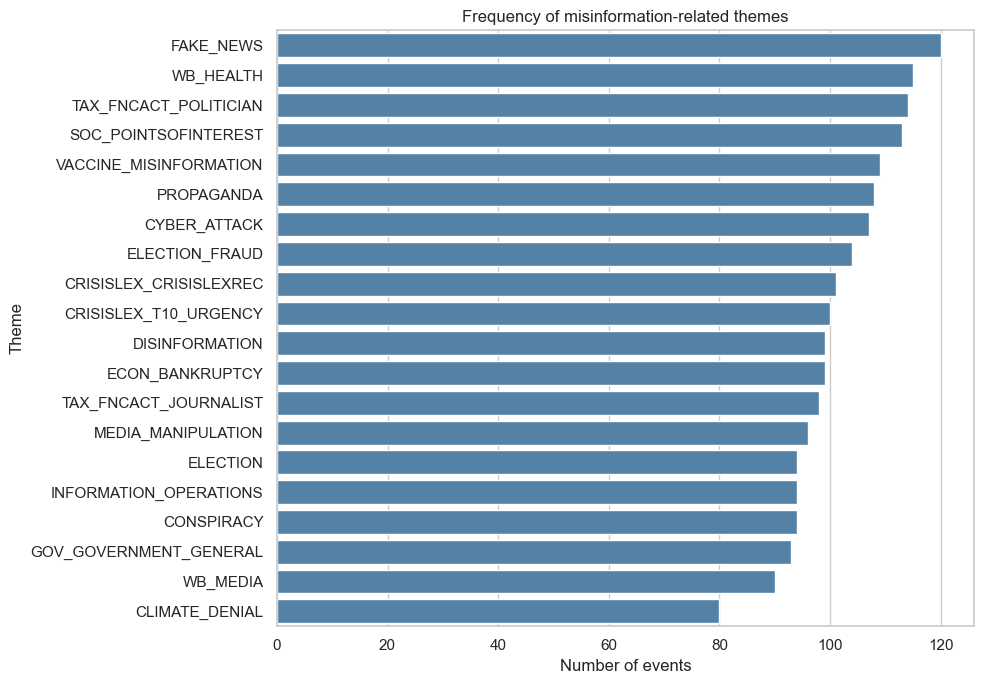

Theme_Tokens
FAKE_NEWS                 120
WB_HEALTH                 115
TAX_FNCACT_POLITICIAN     114
SOC_POINTSOFINTEREST      113
VACCINE_MISINFORMATION    109
PROPAGANDA                108
CYBER_ATTACK              107
ELECTION_FRAUD            104
CRISISLEX_CRISISLEXREC    101
CRISISLEX_T10_URGENCY     100
DISINFORMATION             99
ECON_BANKRUPTCY            99
TAX_FNCACT_JOURNALIST      98
MEDIA_MANIPULATION         96
ELECTION                   94
INFORMATION_OPERATIONS     94
CONSPIRACY                 94
GOV_GOVERNMENT_GENERAL     93
WB_MEDIA                   90
CLIMATE_DENIAL             80
Name: count, dtype: int64

In [16]:
# --- Theme frequency across all events ---
theme_counts = df["Theme_Tokens"].explode().value_counts()

plt.figure(figsize=(10, 7))
sns.barplot(x=theme_counts.values, y=theme_counts.index, color="steelblue")
plt.xlabel("Number of events")
plt.ylabel("Theme")
plt.title("Frequency of misinformation-related themes")
plt.tight_layout()
plt.show()

theme_counts


In [17]:
# --- Dominant narratives per country (top theme per country) ---
theme_by_country = (
    df.explode("Theme_Tokens")
      .groupby(["Country", "Theme_Tokens"])
      .size()
      .reset_index(name="Count")
)

top_theme_per_country = (
    theme_by_country
    .sort_values("Count", ascending=False)
    .groupby("Country")
    .first()
    .sort_values("Count", ascending=False)
)
top_theme_per_country


,Theme_Tokens,Count
Country,,
South Africa,PROPAGANDA,15
Pakistan,CRISISLEX_T10_URGENCY,11
Indonesia,PROPAGANDA,10
Ukraine,FAKE_NEWS,10
Ethiopia,VACCINE_MISINFORMATION,10
Nigeria,CRISISLEX_CRISISLEXREC,10
Mexico,CRISISLEX_CRISISLEXREC,9
Turkey,SOC_POINTSOFINTEREST,9
United Kingdom,WB_HEALTH,9


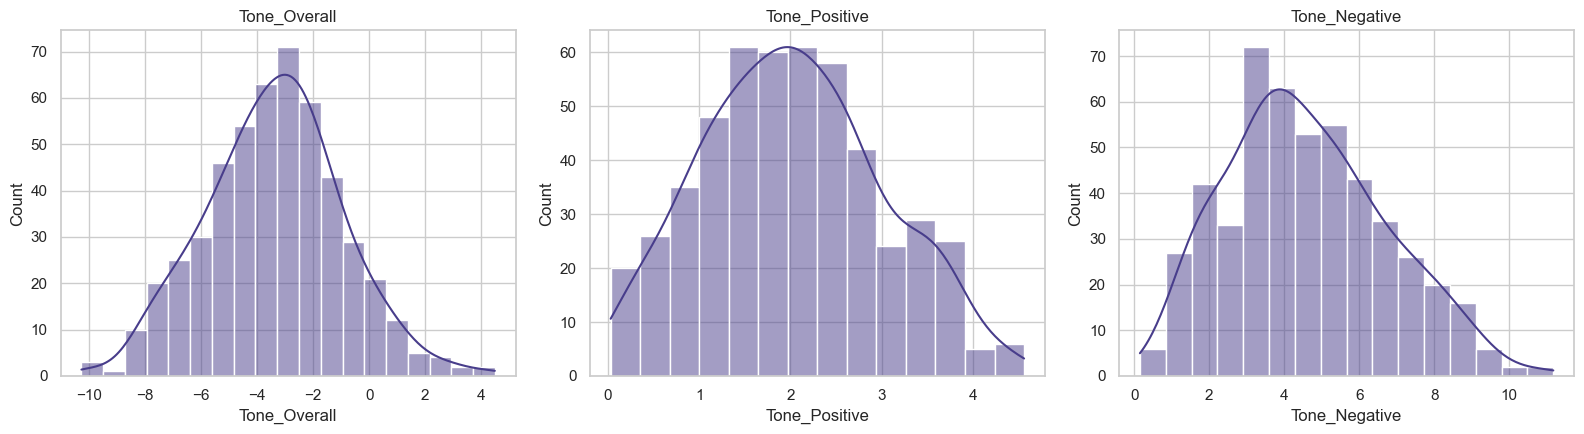

In [18]:
# --- Tone distributions ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["Tone_Overall", "Tone_Positive", "Tone_Negative"]):
    sns.histplot(df[col], kde=True, ax=ax, color="darkslateblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


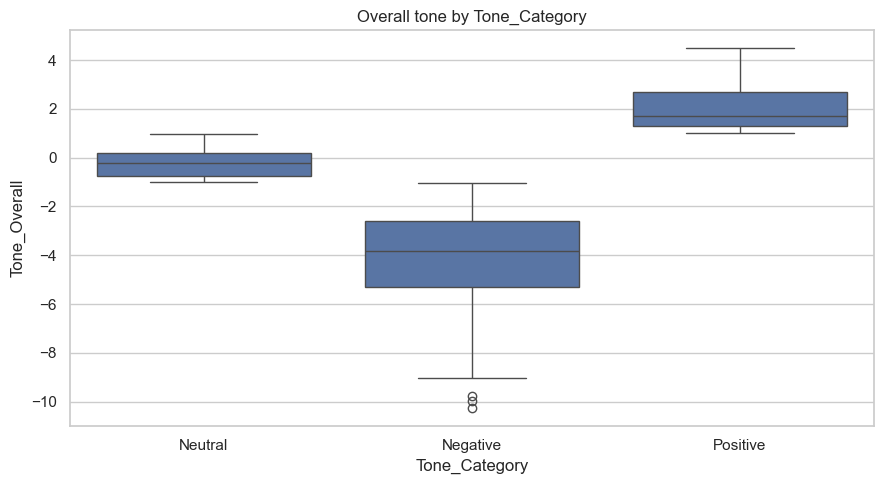

In [19]:
# --- Tone by Context_Category / Tone_Category ---
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Tone_Category", y="Tone_Overall")
plt.title("Overall tone by Tone_Category")
plt.tight_layout()
plt.show()


In [20]:
# --- Topic vs. tone: mean tone scores per LDA topic ---
topic_tone = df.groupby("Topic_Label")[["Tone_Overall", "Tone_Positive", "Tone_Negative", "Tone_Polarity"]].mean().round(2)
topic_tone


,Tone_Overall,Tone_Positive,Tone_Negative,Tone_Polarity
Topic_Label,,,,
Topic 0,-3.24,2.07,4.53,6.60
Topic 1,-3.34,2.10,4.62,6.72
Topic 2,-3.58,2.09,4.77,6.86
Topic 3,-3.66,1.98,4.84,6.82
Topic 4,-3.08,1.89,4.20,6.09


## 6. Geographic clustering and hotspots (spatial analysis)

In [21]:
# --- Convert to a GeoDataFrame ---
geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]
gdf = gpd.GeoDataFrame(df.copy(), geometry=geometry, crs="EPSG:4326")
gdf.head()


,Record_ID,Date,Year,Month,Month_Name,Quarter,Year_Month,Source,Source_URL,Country,...,Tone_Negative,Tone_Polarity,Tone_Activity,Tone_SelfGroup,Context_Category,Tone_Category,Theme_Tokens,Topic_ID,Topic_Label,geometry
0,GDELT-SYNTHETIC-20220101-00333,2022-01-01,2022,1,January,Q1,2022-01,The Guardian,https://www.theguardian.com/news/2022/01/01/so...,Brazil,...,0.15,2.03,6.18,3.80,CRISISLEX_C07;15;1;Brazil;-14.23;-51.92,Neutral,"[ELECTION, CYBER_ATTACK, VACCINE_MISINFORMATIO...",2,Topic 2,POINT (-51.92 -14.23)
1,GDELT-SYNTHETIC-20220102-00214,2022-01-02,2022,1,January,Q1,2022-01,Deutsche Welle,https://www.dw.com/news/2022/01/02/fact-check-...,Ghana,...,7.88,8.59,6.60,2.85,ARREST;34;1;Ghana;7.94;-1.02,Negative,"[TAX_FNCACT_POLITICIAN, CRISISLEX_CRISISLEXREC...",0,Topic 0,POINT (-1.02 7.94)
2,GDELT-SYNTHETIC-20220105-00391,2022-01-05,2022,1,January,Q1,2022-01,Al Jazeera,https://www.aljazeera.com/news/2022/01/05/poli...,United Kingdom,...,8.48,11.74,6.04,1.90,ARREST;19;1;United Kingdom;55.37;-3.43,Negative,"[DISINFORMATION, WB_MEDIA, ELECTION, CYBER_ATT...",3,Topic 3,POINT (-3.43 55.37)
3,GDELT-SYNTHETIC-20220106-00173,2022-01-06,2022,1,January,Q1,2022-01,Al Jazeera,https://www.aljazeera.com/news/2022/01/06/fact...,Ukraine,...,4.76,5.24,13.39,1.89,PROTEST;23;1;Ukraine;48.37;31.16,Negative,"[FAKE_NEWS, WB_HEALTH, ELECTION_FRAUD, CRISISL...",3,Topic 3,POINT (31.16 48.37)
4,GDELT-SYNTHETIC-20220108-00334,2022-01-08,2022,1,January,Q1,2022-01,The Guardian,https://www.theguardian.com/news/2022/01/08/re...,Mexico,...,4.31,5.31,10.52,3.05,ARREST;17;1;Mexico;23.63;-102.55,Negative,"[CRISISLEX_CRISISLEXREC, GOV_GOVERNMENT_GENERA...",0,Topic 0,POINT (-102.55 23.63)


Could not load built-in basemap: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
Download a countries shapefile from naturalearthdata.com and load it with gpd.read_file(...)


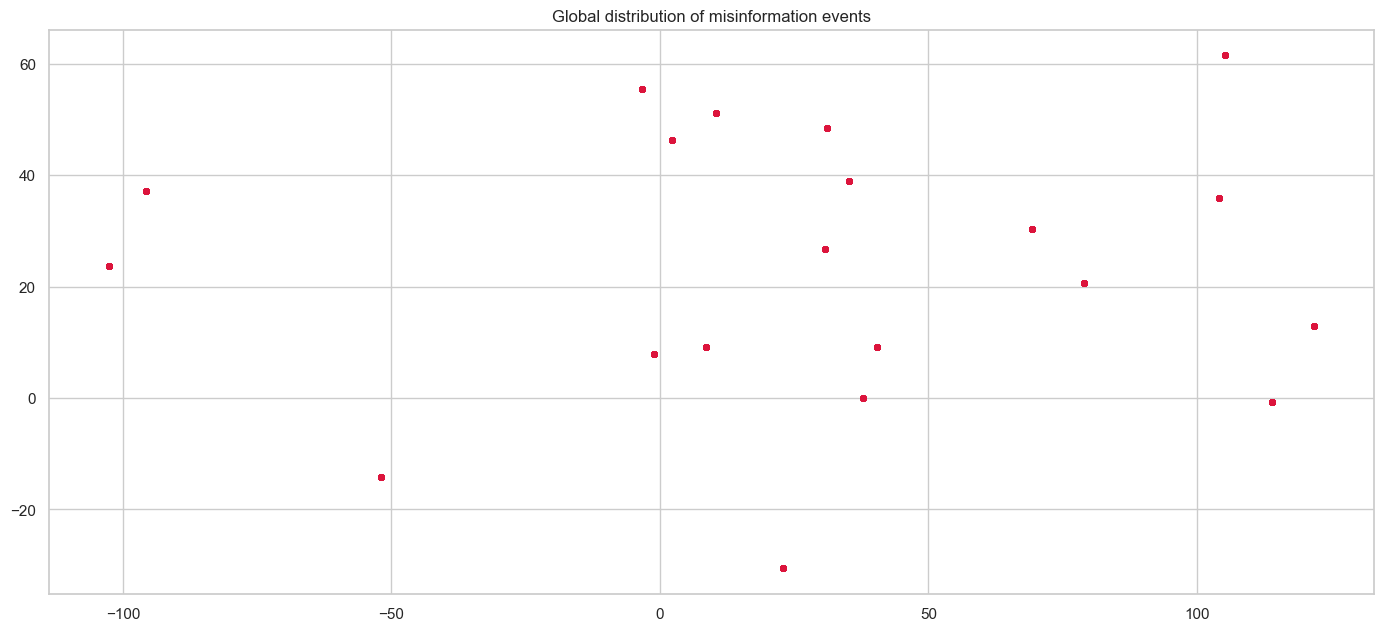

In [22]:
# --- Plot events over a world basemap ---
# Requires the 'naturalearth_lowres' dataset shipped with older geopandas, or download one yourself:
# world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
# If gpd.datasets is unavailable in your geopandas version, download a shapefile from
# https://www.naturalearthdata.com and load it with gpd.read_file("path/to/ne_110m_admin_0_countries.shp")

try:
    world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
except Exception as e:
    print("Could not load built-in basemap:", e)
    print("Download a countries shapefile from naturalearthdata.com and load it with gpd.read_file(...)")
    world = None

fig, ax = plt.subplots(figsize=(14, 8))
if world is not None:
    world.plot(ax=ax, color="whitesmoke", edgecolor="lightgray")
gdf.plot(ax=ax, markersize=15, color="crimson", alpha=0.6)
ax.set_title("Global distribution of misinformation events")
plt.tight_layout()
plt.show()


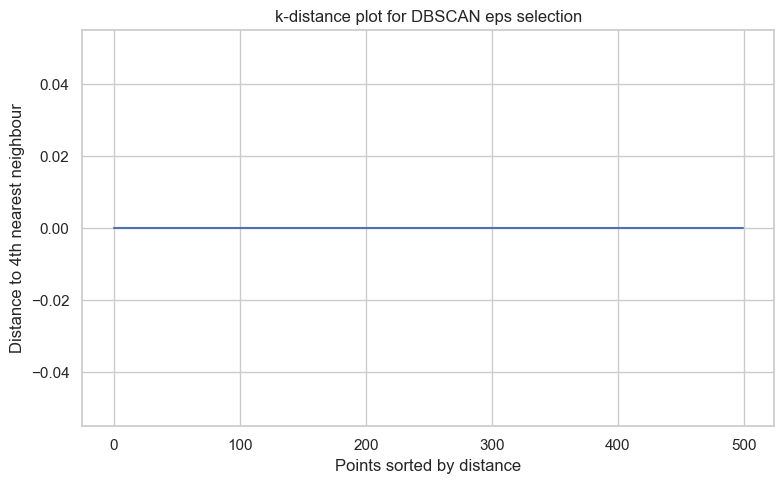

In [23]:
# --- DBSCAN clustering ---
coords = gdf[["Longitude", "Latitude"]].to_numpy()

# k-distance plot to help choose eps (look for the "elbow")
MIN_SAMPLES = 4
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(coords)
distances, _ = neighbors.kneighbors(coords)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbour")
plt.title("k-distance plot for DBSCAN eps selection")
plt.tight_layout()
plt.show()


DBSCAN found 20 clusters and 0 noise points (label -1)


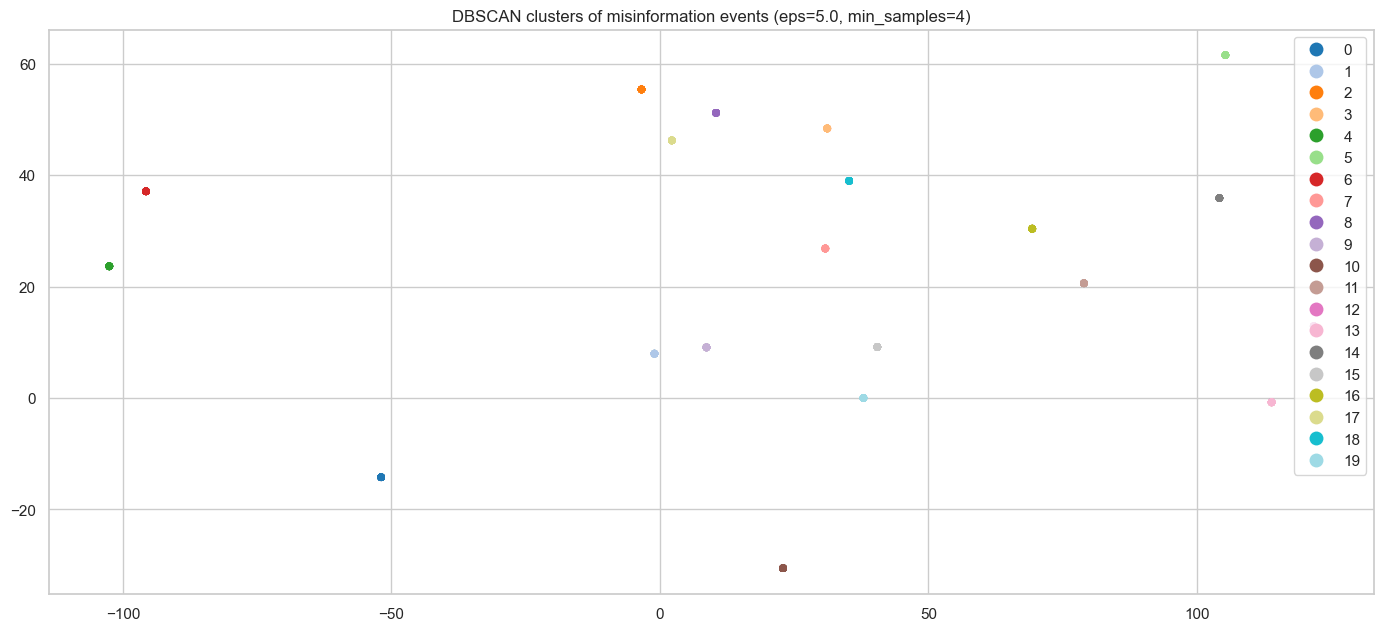

In [24]:
# Set eps based on the elbow in the plot above (degrees of lat/lon, since coordinates aren't projected)
EPS = 5.0          # <-- adjust after inspecting the k-distance plot
MIN_SAMPLES = 4

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(coords)
gdf["Cluster_ID"] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points (label -1)")

fig, ax = plt.subplots(figsize=(14, 8))
if world is not None:
    world.plot(ax=ax, color="whitesmoke", edgecolor="lightgray")
gdf.plot(ax=ax, column="Cluster_ID", categorical=True, markersize=20, legend=True, cmap="tab20")
ax.set_title(f"DBSCAN clusters of misinformation events (eps={EPS}, min_samples={MIN_SAMPLES})")
plt.tight_layout()
plt.show()


In [25]:
# --- Moran's I: spatial autocorrelation of event counts at the country level ---
# Aggregate to country level
country_counts = df.groupby("Country").agg(
    Misinfo_Event_Count=("Record_ID", "count"),
    Mean_Tone=("Tone_Overall", "mean"),
    Latitude=("Latitude", "mean"),
    Longitude=("Longitude", "mean"),
).reset_index()

country_gdf = gpd.GeoDataFrame(
    country_counts,
    geometry=[Point(xy) for xy in zip(country_counts["Longitude"], country_counts["Latitude"])],
    crs="EPSG:4326",
)

# Distance/contiguity-based spatial weights (K-nearest-neighbour weights on country centroids)
w = KNN.from_dataframe(country_gdf, k=4)
w.transform = "r"

moran_counts = Moran(country_gdf["Misinfo_Event_Count"].values, w)
moran_tone = Moran(country_gdf["Mean_Tone"].values, w)

print(f"Moran's I (event counts): I={moran_counts.I:.4f}, p-value={moran_counts.p_sim:.4f}")
print(f"Moran's I (mean tone):    I={moran_tone.I:.4f}, p-value={moran_tone.p_sim:.4f}")


Moran's I (event counts): I=-0.0570, p-value=0.4640
Moran's I (mean tone):    I=-0.1388, p-value=0.2230


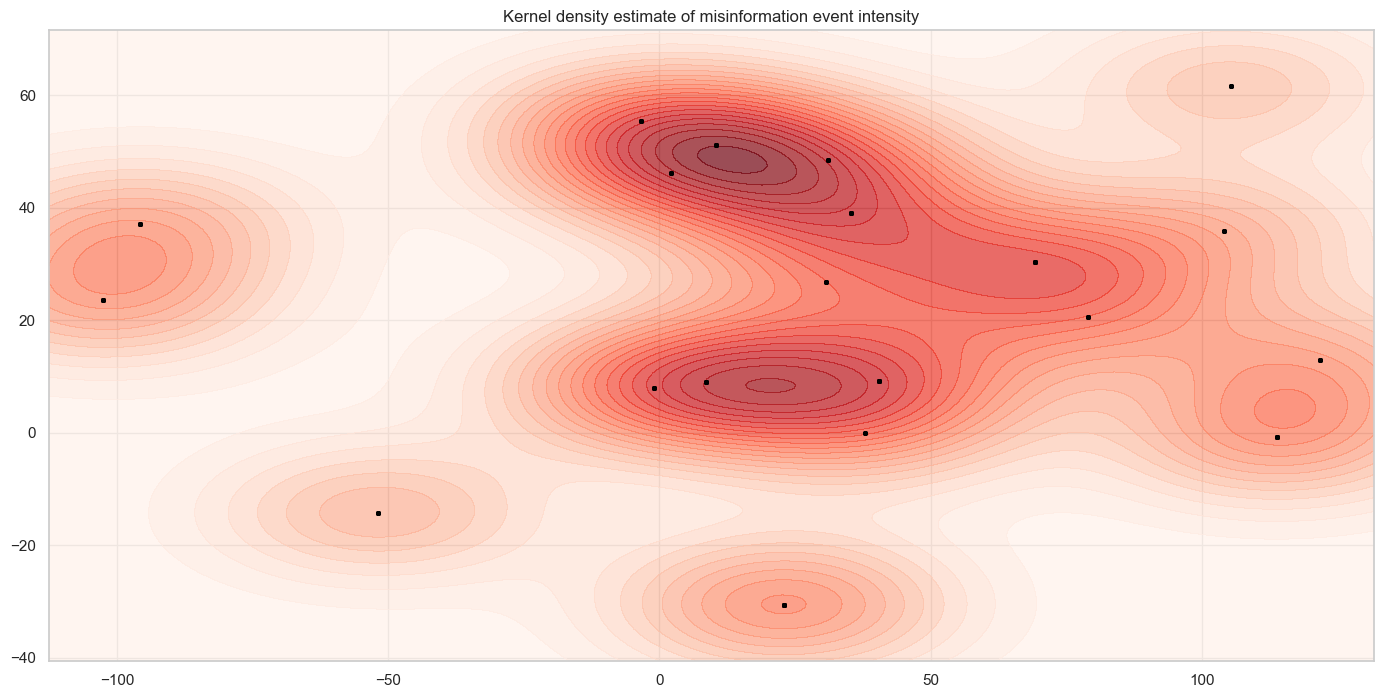

In [26]:
# --- Kernel Density Estimation of event intensity ---
xy = np.vstack([gdf["Longitude"], gdf["Latitude"]])
kde = gaussian_kde(xy)

xmin, xmax = gdf["Longitude"].min() - 10, gdf["Longitude"].max() + 10
ymin, ymax = gdf["Latitude"].min() - 10, gdf["Latitude"].max() + 10
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
density = np.reshape(kde(positions).T, xx.shape)

fig, ax = plt.subplots(figsize=(14, 8))
if world is not None:
    world.plot(ax=ax, color="none", edgecolor="lightgray")
ax.contourf(xx, yy, density, levels=25, cmap="Reds", alpha=0.7)
gdf.plot(ax=ax, markersize=6, color="black", alpha=0.4)
ax.set_title("Kernel density estimate of misinformation event intensity")
plt.tight_layout()
plt.show()


## 7. Construct contextual variables

In [27]:
# --- Infer political / economic / health context from theme tags ---
POLITICAL_THEMES = {"ELECTION", "ELECTION_FRAUD", "PROPAGANDA", "GOV_GOVERNMENT_GENERAL",
                     "TAX_FNCACT_POLITICIAN", "INFORMATION_OPERATIONS"}
ECONOMIC_THEMES  = {"ECON_BANKRUPTCY", "MEDIA_MANIPULATION"}
HEALTH_THEMES    = {"WB_HEALTH", "VACCINE_MISINFORMATION"}

def flag_context(tokens, keyword_set):
    return int(len(set(tokens) & keyword_set) > 0)

df["Political_Context"] = df["Theme_Tokens"].apply(lambda t: flag_context(t, POLITICAL_THEMES))
df["Economic_Context"]  = df["Theme_Tokens"].apply(lambda t: flag_context(t, ECONOMIC_THEMES))
df["Health_Context"]    = df["Theme_Tokens"].apply(lambda t: flag_context(t, HEALTH_THEMES))

df[["Political_Context", "Economic_Context", "Health_Context"]].mean().rename("Share of events")


Political_Context    0.748
Economic_Context     0.350
Health_Context       0.400
Name: Share of events, dtype: float64

In [28]:
# --- Aggregate to Country x Year_Month level ---
country_month = df.groupby(["Country", "Year_Month"]).agg(
    Misinfo_Event_Count=("Record_ID", "count"),
    Political_Prop=("Political_Context", "mean"),
    Economic_Prop=("Economic_Context", "mean"),
    Health_Prop=("Health_Context", "mean"),
    Tone_Overall_Mean=("Tone_Overall", "mean"),
    Source_Diversity=("Source", "nunique"),
).reset_index()

print(country_month.shape)
country_month.head(10)


(311, 8)


,Country,Year_Month,Misinfo_Event_Count,Political_Prop,Economic_Prop,Health_Prop,Tone_Overall_Mean,Source_Diversity
0,Brazil,2022-01,1,1.0,0.00,1.00,-0.210,1
1,Brazil,2022-02,1,0.0,1.00,1.00,-5.800,1
2,Brazil,2022-03,2,0.5,0.50,0.00,0.040,1
3,Brazil,2022-04,2,0.5,0.00,0.50,-0.035,2
4,Brazil,2022-05,4,1.0,0.25,0.25,-1.340,3
5,Brazil,2022-07,1,1.0,0.00,0.00,4.480,1
6,Brazil,2022-10,1,1.0,0.00,1.00,-0.700,1
7,Brazil,2022-12,1,1.0,1.00,1.00,-7.640,1
8,Brazil,2023-02,2,1.0,0.00,0.00,-2.475,1
9,Brazil,2023-04,1,1.0,0.00,0.00,-1.410,1


In [29]:
# Optional: merge external context data here (election periods, GDP/inflation, COVID case counts),
# joined on Country + Year_Month, e.g.:
#
# external = pd.read_csv("external_context.csv")   # columns: Country, Year_Month, is_election_month, covid_cases, ...
# country_month = country_month.merge(external, on=["Country", "Year_Month"], how="left")


## 8. Contextual drivers via count-based regression

In [30]:
# --- Prepare the modelling dataset (Country-Month rows) ---
model_df = country_month.copy()
model_df = model_df.dropna(subset=["Misinfo_Event_Count", "Political_Prop", "Economic_Prop", "Health_Prop"])

model_df.describe()


,Misinfo_Event_Count,Political_Prop,Economic_Prop,Health_Prop,Tone_Overall_Mean,Source_Diversity
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,1.607717,0.733119,0.349143,0.393569,-3.324699,1.498392
std,0.850316,0.391587,0.416040,0.417650,2.124566,0.685681
min,1.000000,0.000000,0.000000,0.000000,-8.380000,1.000000
25%,1.000000,0.500000,0.000000,0.000000,-4.752500,1.000000
50%,1.000000,1.000000,0.000000,0.333333,-3.246667,1.000000
75%,2.000000,1.000000,0.666667,1.000000,-2.065000,2.000000
max,6.000000,1.000000,1.000000,1.000000,4.480000,4.000000


In [31]:
# --- Poisson regression ---
poisson_formula = "Misinfo_Event_Count ~ Political_Prop + Economic_Prop + Health_Prop + Tone_Overall_Mean"

poisson_model = smf.glm(
    formula=poisson_formula,
    data=model_df,
    family=sm.families.Poisson(),
).fit()

print(poisson_model.summary())


                  Generalized Linear Model Regression Results                  
Dep. Variable:     Misinfo_Event_Count   No. Observations:                  311
Model:                             GLM   Df Residuals:                      306
Model Family:                  Poisson   Df Model:                            4
Link Function:                     Log   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -420.74
Date:                 Mon, 20 Jul 2026   Deviance:                       118.41
Time:                         15:55:12   Pearson chi2:                     138.
No. Iterations:                      4   Pseudo R-squ. (CS):           0.004303
Covariance Type:             nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.3239

In [32]:
# --- Check for overdispersion (variance vs mean of the dependent variable) ---
mean_count = model_df["Misinfo_Event_Count"].mean()
var_count = model_df["Misinfo_Event_Count"].var()
dispersion_ratio = var_count / mean_count

print(f"Mean(Misinfo_Event_Count) = {mean_count:.3f}")
print(f"Var(Misinfo_Event_Count)  = {var_count:.3f}")
print(f"Dispersion ratio (var/mean) = {dispersion_ratio:.3f}")
print("-> Overdispersion suspected (fit Negative Binomial)" if dispersion_ratio > 1.5 else "-> Poisson assumption looks reasonable")

# Pearson chi2 / degrees of freedom is another standard overdispersion diagnostic
pearson_chi2 = poisson_model.pearson_chi2
df_resid = poisson_model.df_resid
print(f"Pearson chi2 / df = {pearson_chi2 / df_resid:.3f} (values well above 1 indicate overdispersion)")


Mean(Misinfo_Event_Count) = 1.608
Var(Misinfo_Event_Count)  = 0.723
Dispersion ratio (var/mean) = 0.450
-> Poisson assumption looks reasonable
Pearson chi2 / df = 0.450 (values well above 1 indicate overdispersion)


In [33]:
# --- Negative Binomial regression (fit if overdispersion is present) ---
# NB: smf.glm(family=sm.families.NegativeBinomial()) fixes alpha=1.0 by default, which
# is rarely the true dispersion in your data (hence the ValueWarning). Instead, we use
# smf.negativebinomial(), which estimates alpha from the data via maximum likelihood.
nb_model = smf.negativebinomial(
    formula=poisson_formula,
    data=model_df,
).fit(disp=False)

print(nb_model.summary())
print(f"\nEstimated dispersion parameter alpha = {nb_model.params['alpha']:.4f}")


                      NegativeBinomial Regression Results                      
Dep. Variable:     Misinfo_Event_Count   No. Observations:                  311
Model:                NegativeBinomial   Df Residuals:                      306
Method:                            MLE   Df Model:                            4
Date:                 Mon, 20 Jul 2026   Pseudo R-squ.:                     nan
Time:                         15:55:16   Log-Likelihood:                -420.74
converged:                        True   LL-Null:                           nan
Covariance Type:             nonrobust   LLR p-value:                       nan
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.3238      0.143      2.262      0.024       0.043       0.604
Political_Prop        0.1110      0.119      0.929      0.353      -0.123       0.345
Economic_Prop   

C:\Users\Administrator\anaconda3\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\Administrator\anaconda3\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [34]:
# --- Interpret coefficients as Incidence Rate Ratios (IRRs) ---
def irr_table(fitted_model):
    params = fitted_model.params.drop(labels=["alpha"], errors="ignore")  # alpha is a dispersion param, not a rate ratio
    conf = fitted_model.conf_int().drop(index=["alpha"], errors="ignore")
    conf.columns = ["ci_lower", "ci_upper"]
    out = pd.DataFrame({
        "coef": params,
        "IRR": np.exp(params),
        "IRR_ci_lower": np.exp(conf["ci_lower"]),
        "IRR_ci_upper": np.exp(conf["ci_upper"]),
        "p_value": fitted_model.pvalues.drop(labels=["alpha"], errors="ignore"),
    })
    return out.round(3)

print("Poisson model - Incidence Rate Ratios")
display(irr_table(poisson_model))

print("\nNegative Binomial model - Incidence Rate Ratios")
display(irr_table(nb_model))


Poisson model - Incidence Rate Ratios


,coef,IRR,IRR_ci_lower,IRR_ci_upper,p_value
Intercept,0.324,1.382,1.044,1.830,0.024
Political_Prop,0.111,1.117,0.884,1.412,0.353
Economic_Prop,0.023,1.024,0.826,1.269,0.831
Health_Prop,0.047,1.048,0.848,1.296,0.665
Tone_Overall_Mean,-0.013,0.988,0.947,1.029,0.554



Negative Binomial model - Incidence Rate Ratios


,coef,IRR,IRR_ci_lower,IRR_ci_upper,p_value
Intercept,0.324,1.382,1.044,1.830,0.024
Political_Prop,0.111,1.117,0.884,1.412,0.353
Economic_Prop,0.023,1.024,0.826,1.269,0.830
Health_Prop,0.047,1.048,0.848,1.296,0.665
Tone_Overall_Mean,-0.013,0.988,0.947,1.029,0.554


## 9. Final analysis and visualisation outputs

In [35]:
# --- Key findings summary tables ---
print("=== Dominant misinformation themes ===")
print(theme_counts.head(5), "\n")

print("=== Mean tone by topic ===")
print(topic_tone, "\n")

print("=== Countries with highest event counts ===")
print(country_counts.sort_values("Misinfo_Event_Count", ascending=False).head(5), "\n")

print("=== Moran's I results ===")
print(f"Event counts: I={moran_counts.I:.4f} (p={moran_counts.p_sim:.4f})")
print(f"Mean tone:    I={moran_tone.I:.4f} (p={moran_tone.p_sim:.4f})\n")

print("=== Negative Binomial IRRs (contextual drivers) ===")
print(irr_table(nb_model))


=== Dominant misinformation themes ===
Theme_Tokens
FAKE_NEWS                 120
WB_HEALTH                 115
TAX_FNCACT_POLITICIAN     114
SOC_POINTSOFINTEREST      113
VACCINE_MISINFORMATION    109
Name: count, dtype: int64 

=== Mean tone by topic ===
             Tone_Overall  Tone_Positive  Tone_Negative  Tone_Polarity
Topic_Label                                                           
Topic 0             -3.24           2.07           4.53           6.60
Topic 1             -3.34           2.10           4.62           6.72
Topic 2             -3.58           2.09           4.77           6.86
Topic 3             -3.66           1.98           4.84           6.82
Topic 4             -3.08           1.89           4.20           6.09 

=== Countries with highest event counts ===
         Country  Misinfo_Event_Count  Mean_Tone  Latitude  Longitude
15  South Africa                   36  -3.874167    -30.55      22.93
3       Ethiopia                   33  -3.123333      9.14  

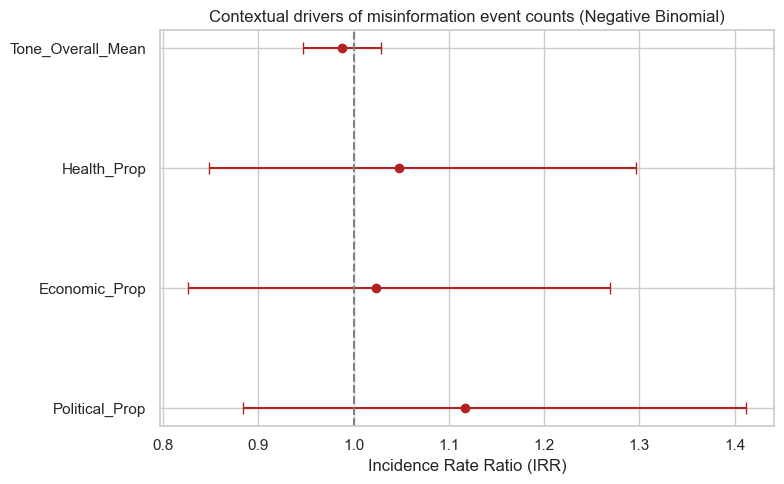

In [36]:
# --- Effect plot: IRRs with confidence intervals ---
irr_df = irr_table(nb_model).drop(index="Intercept", errors="ignore")

plt.figure(figsize=(8, 5))
plt.errorbar(
    irr_df["IRR"], irr_df.index,
    xerr=[irr_df["IRR"] - irr_df["IRR_ci_lower"], irr_df["IRR_ci_upper"] - irr_df["IRR"]],
    fmt="o", capsize=4, color="firebrick",
)
plt.axvline(1, linestyle="--", color="gray")
plt.xlabel("Incidence Rate Ratio (IRR)")
plt.title("Contextual drivers of misinformation event counts (Negative Binomial)")
plt.tight_layout()
plt.show()


In [37]:
# --- Save key outputs for use in your report/thesis chapter ---
import os
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

df.to_csv(f"{OUT_DIR}/cleaned_events_with_topics.csv", index=False)
country_month.to_csv(f"{OUT_DIR}/country_month_panel.csv", index=False)
theme_counts.to_csv(f"{OUT_DIR}/theme_frequencies.csv")
topic_tone.to_csv(f"{OUT_DIR}/topic_vs_tone.csv")
irr_table(nb_model).to_csv(f"{OUT_DIR}/negative_binomial_irr.csv")

print(f"Saved cleaned data, panel dataset, and result tables to ./{OUT_DIR}/")


Saved cleaned data, panel dataset, and result tables to ./outputs/


### Notes for your write-up
- **Themes:** report which topics dominate overall and how that varies by country (Section 5).
- **Geography:** report DBSCAN cluster count/locations, Moran's I significance (clustered vs random), and KDE hotspots (Section 6).
- **Context:** report which of Political/Economic/Health context proportions have IRR significantly different from 1, and in which direction (Section 8).
- Revisit `EPS`/`MIN_SAMPLES` (DBSCAN) and `NUM_TOPICS` (LDA) - these are analytic choices that should be justified in your methodology, not just left at their defaults.
